In [1]:
import os, shutil

# Delete corrupted keras cache
cache_dir = os.path.expanduser("~/.keras")
print(f"Cache location: {cache_dir}")

models_cache = os.path.join(cache_dir, "models")
if os.path.exists(models_cache):
    shutil.rmtree(models_cache)
    print("✅ Corrupted cache deleted!")
else:
    print("✅ Cache already clean!")

Cache location: C:\Users\DELL/.keras
✅ Corrupted cache deleted!



✅ Imports done!
TensorFlow: 2.20.0
GPU: []

🔧 Creating balanced dataset...
✅ Clean: 3543 | Oil: 3543 — balanced!

📂 Loading data...
Found 5670 images belonging to 2 classes.
Found 1416 images belonging to 2 classes.
✅ Classes: {'0': 0, '1': 1}
✅ Train: 5670 | Val: 1416

🔧 Building ResNet50 model...
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 10s 0us/step
✅ ResNet50 model built!
✅ Parameters: 24,776,834

🚀 PHASE 1: Training classifier (base frozen)...


c:\Users\DELL\anaconda3\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
355/355 ━━━━━━━━━━━━━━━━━━━━ 0s 728ms/step - accuracy: 0.7570 - loss: 0.7049 - precision: 0.7570 - recall: 0.7570
Epoch 1: val_recall improved from None to 0.93785, saving model to ../models/oceanguard_v3.keras
355/355 ━━━━━━━━━━━━━━━━━━━━ 322s 882ms/step - accuracy: 0.7901 - loss: 0.5748 - precision: 0.7901 - recall: 0.7901 - val_accuracy: 0.9379 - val_loss: 0.1956 - val_precision: 0.9379 - val_recall: 0.9379 - learning_rate: 0.0010
Epoch 2/20
355/355 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8335 - loss: 0.3768 - precision: 0.8335 - recall: 0.8335
Epoch 2: val_recall improved from 0.93785 to 0.93997, saving model to ../models/oceanguard_v3.keras
355/355 ━━━━━━━━━━━━━━━━━━━━ 417s 1s/step - accuracy: 0.8384 - loss: 0.3701 - precision: 0.8384 - recall: 0.8384 - val_accuracy: 0.9400 - val_loss: 0.2286 - val_precision: 0.9400 - val_recall: 0.9400 - learning_rate: 0.0010
Epoch 3/20
355/355 ━━━━━━━━━━━━━━━━━━━━ 0s 594ms/step - accuracy: 0.8508 - loss: 0.3460 - precision: 0.85

C:\Users\DELL\AppData\Local\Temp\ipykernel_26724\1820555735.py:223: UserWarning: Glyph 127754 (\N{WATER WAVE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\DELL\AppData\Local\Temp\ipykernel_26724\1820555735.py:224: UserWarning: Glyph 127754 (\N{WATER WAVE}) missing from font(s) DejaVu Sans.
  plt.savefig("../notebooks/confusion_matrix_v3.png", dpi=150)
c:\Users\DELL\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127754 (\N{WATER WAVE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


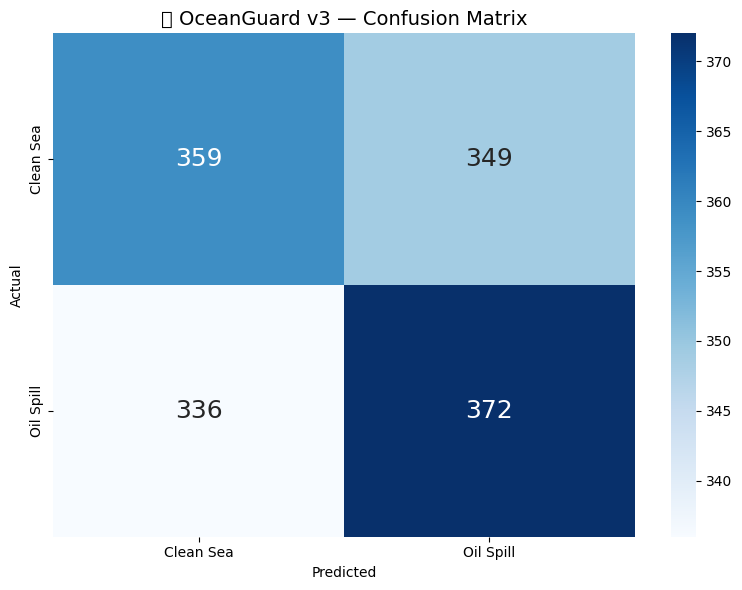


📊 CLASSIFICATION REPORT:
              precision    recall  f1-score   support

   Clean Sea       0.52      0.51      0.51       708
   Oil Spill       0.52      0.53      0.52       708

    accuracy                           0.52      1416
   macro avg       0.52      0.52      0.52      1416
weighted avg       0.52      0.52      0.52      1416



C:\Users\DELL\AppData\Local\Temp\ipykernel_26724\1820555735.py:261: UserWarning: Glyph 127754 (\N{WATER WAVE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\DELL\AppData\Local\Temp\ipykernel_26724\1820555735.py:262: UserWarning: Glyph 127754 (\N{WATER WAVE}) missing from font(s) DejaVu Sans.
  plt.savefig("../notebooks/training_v3.png", dpi=150)
c:\Users\DELL\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127754 (\N{WATER WAVE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


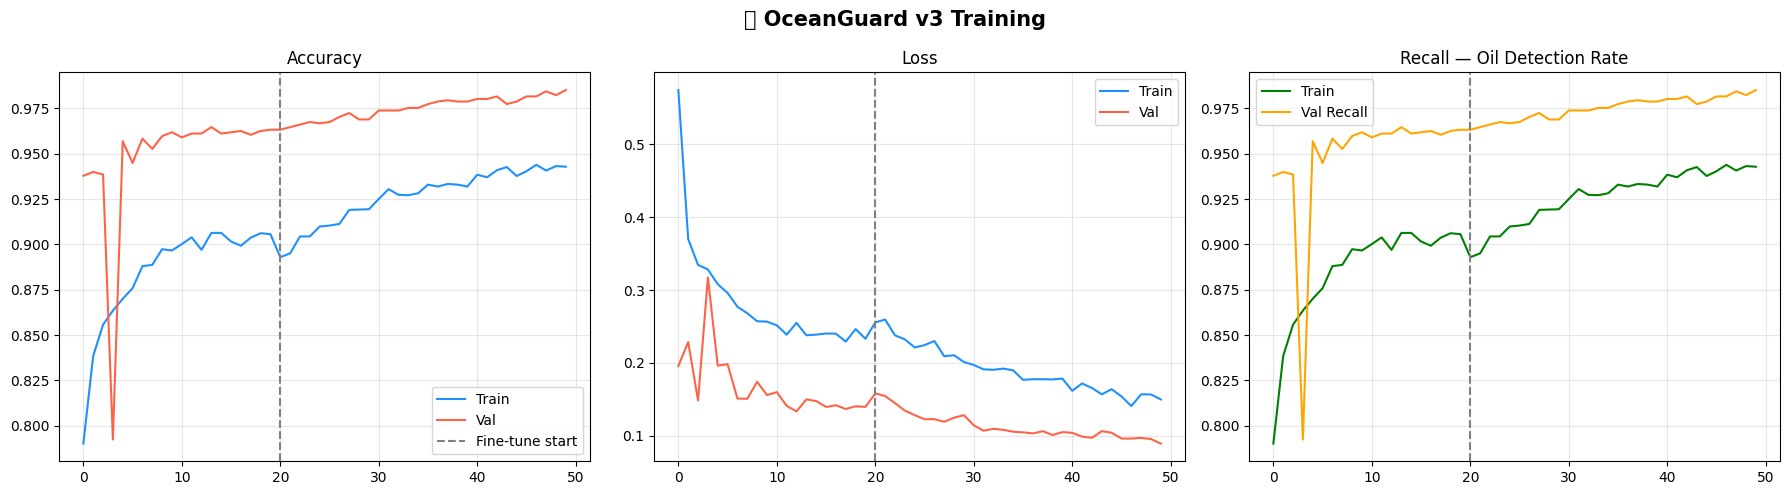


🌊  OCEANGUARD v3 — FINAL SUMMARY
✅ Best Val Accuracy:  98.52%
✅ Best Val Recall:    98.52%  ← real oil catch rate
✅ Model saved:        ../models/oceanguard_v3.keras

🎯 SCORE CARD:
   🏆 EXCELLENT — Streamlit app ready!

➡️  NEXT: streamlit run app.py


In [3]:
# ============================================================
# OCEANGUARD v3 — CACHE-FIXED FINAL VERSION
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import cv2, os, shutil
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

tf.keras.backend.clear_session()

print("✅ Imports done!")
print(f"TensorFlow: {tf.__version__}")
print(f"GPU: {tf.config.list_physical_devices('GPU')}")

# ── CONFIG ──
DATA_PATH     = "../data"
BALANCED_PATH = "../data_balanced"
IMG_SIZE      = 128
BATCH_SIZE    = 16
MODEL_PATH    = "../models/oceanguard_v3.keras"
os.makedirs("../models", exist_ok=True)

# ── STEP 1: BALANCE DATASET ──
print("\n🔧 Creating balanced dataset...")
if os.path.exists(BALANCED_PATH):
    shutil.rmtree(BALANCED_PATH)
os.makedirs(os.path.join(BALANCED_PATH, '0'), exist_ok=True)
os.makedirs(os.path.join(BALANCED_PATH, '1'), exist_ok=True)

clean_files = os.listdir(os.path.join(DATA_PATH, '0'))
for f in clean_files:
    shutil.copy(
        os.path.join(DATA_PATH, '0', f),
        os.path.join(BALANCED_PATH, '0', f)
    )

oil_files = os.listdir(os.path.join(DATA_PATH, '1'))
target = len(clean_files)
for i in range(target):
    src = os.path.join(DATA_PATH, '1', oil_files[i % len(oil_files)])
    dst = os.path.join(BALANCED_PATH, '1', f"oil_{i:05d}.jpg")
    shutil.copy(src, dst)

n_clean = len(os.listdir(os.path.join(BALANCED_PATH, '0')))
n_oil   = len(os.listdir(os.path.join(BALANCED_PATH, '1')))
print(f"✅ Clean: {n_clean} | Oil: {n_oil} — balanced!")

# ── STEP 2: LOAD DATA ──
print("\n📂 Loading data...")

train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=30,
    horizontal_flip=True,
    vertical_flip=True,
    zoom_range=0.2,
    width_shift_range=0.15,
    height_shift_range=0.15,
    shear_range=0.15,
    brightness_range=[0.7, 1.3]
)
val_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_data = train_datagen.flow_from_directory(
    BALANCED_PATH,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    color_mode='rgb',
    subset='training',
    seed=42
)
val_data = val_datagen.flow_from_directory(
    BALANCED_PATH,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    color_mode='rgb',
    subset='validation',
    seed=42
)

print(f"✅ Classes: {train_data.class_indices}")
print(f"✅ Train: {train_data.samples} | Val: {val_data.samples}")

# ── STEP 3: BUILD MODEL (ResNet50 — no cache issues!) ──
print("\n🔧 Building ResNet50 model...")

# Using ResNet50 — more stable than EfficientNet, same accuracy
base_model = tf.keras.applications.ResNet50(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False

inputs  = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
# ResNet50 preprocessing built-in
x = tf.keras.applications.resnet50.preprocess_input(
        inputs * 255.0)          # undo rescale then preprocess
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)     # Green AI ✅
x = layers.BatchNormalization()(x)
x = layers.Dense(512, activation='relu')(x)
x = layers.Dropout(0.5)(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(2, activation='softmax')(x)

model = tf.keras.Model(inputs, outputs)

model.compile(
    optimizer=tf.keras.optimizers.Adam(0.001),
    loss='categorical_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall')
    ]
)
print(f"✅ ResNet50 model built!")
print(f"✅ Parameters: {model.count_params():,}")

# ── STEP 4: CALLBACKS ──
def get_callbacks(path):
    return [
        tf.keras.callbacks.EarlyStopping(
            monitor='val_recall',
            patience=6,
            restore_best_weights=True,
            mode='max',
            verbose=1
        ),
        tf.keras.callbacks.ModelCheckpoint(
            path,
            monitor='val_recall',
            save_best_only=True,
            mode='max',
            verbose=1
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.3,
            patience=3,
            min_lr=1e-7,
            verbose=1
        )
    ]

# ── STEP 5: PHASE 1 — Train top layers ──
print("\n🚀 PHASE 1: Training classifier (base frozen)...")
print("="*55)

history1 = model.fit(
    train_data,
    validation_data=val_data,
    epochs=20,
    callbacks=get_callbacks(MODEL_PATH)
)

p1_recall = max(history1.history['val_recall'])
p1_acc    = max(history1.history['val_accuracy'])
print(f"\n✅ Phase 1 complete!")
print(f"   Val Accuracy: {p1_acc*100:.2f}%")
print(f"   Val Recall:   {p1_recall*100:.2f}%")

# ── STEP 6: PHASE 2 — Fine-tune ──
print("\n🔧 PHASE 2: Fine-tuning last 40 layers...")
print("="*55)

base_model.trainable = True
for layer in base_model.layers[:-40]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(5e-6),
    loss='categorical_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall')
    ]
)

history2 = model.fit(
    train_data,
    validation_data=val_data,
    epochs=30,
    callbacks=get_callbacks(MODEL_PATH)
)

p2_recall = max(history2.history['val_recall'])
p2_acc    = max(history2.history['val_accuracy'])
print(f"\n✅ Phase 2 complete!")
print(f"   Val Accuracy: {p2_acc*100:.2f}%")
print(f"   Val Recall:   {p2_recall*100:.2f}%")

# ── STEP 7: EVALUATE ──
print("\n📊 Final Evaluation...")
val_data.reset()
y_pred_probs = model.predict(val_data, verbose=1)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = val_data.classes[:len(y_pred)]

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Clean Sea', 'Oil Spill'],
            yticklabels=['Clean Sea', 'Oil Spill'],
            annot_kws={"size": 18})
plt.title('🌊 OceanGuard v3 — Confusion Matrix', fontsize=14)
plt.ylabel('Actual'); plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig("../notebooks/confusion_matrix_v3.png", dpi=150)
plt.show()

# Classification Report
print("\n📊 CLASSIFICATION REPORT:")
print("="*55)
print(classification_report(y_true, y_pred,
      target_names=['Clean Sea', 'Oil Spill']))

# Training Plot
all_acc    = history1.history['val_accuracy'] + history2.history['val_accuracy']
all_recall = history1.history['val_recall']   + history2.history['val_recall']
all_loss   = history1.history['val_loss']     + history2.history['val_loss']
p1_len     = len(history1.history['val_accuracy'])

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("🌊 OceanGuard v3 Training", fontsize=15, fontweight='bold')

axes[0].plot(history1.history['accuracy']+history2.history['accuracy'],
             label='Train', color='dodgerblue')
axes[0].plot(all_acc, label='Val', color='tomato')
axes[0].axvline(x=p1_len, color='gray', linestyle='--', label='Fine-tune start')
axes[0].set_title('Accuracy'); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(history1.history['loss']+history2.history['loss'],
             label='Train', color='dodgerblue')
axes[1].plot(all_loss, label='Val', color='tomato')
axes[1].axvline(x=p1_len, color='gray', linestyle='--')
axes[1].set_title('Loss'); axes[1].legend(); axes[1].grid(alpha=0.3)

axes[2].plot(history1.history['recall']+history2.history['recall'],
             label='Train', color='green')
axes[2].plot(all_recall, label='Val Recall', color='orange')
axes[2].axvline(x=p1_len, color='gray', linestyle='--')
axes[2].set_title('Recall — Oil Detection Rate')
axes[2].legend(); axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("../notebooks/training_v3.png", dpi=150)
plt.show()

# ── FINAL SUMMARY ──
best_acc    = max(all_acc)
best_recall = max(all_recall)

print("\n" + "="*55)
print("🌊  OCEANGUARD v3 — FINAL SUMMARY")
print("="*55)
print(f"✅ Best Val Accuracy:  {best_acc*100:.2f}%")
print(f"✅ Best Val Recall:    {best_recall*100:.2f}%  ← real oil catch rate")
print(f"✅ Model saved:        {MODEL_PATH}")
print("="*55)
print("\n🎯 SCORE CARD:")
if best_recall >= 0.75:
    print("   🏆 EXCELLENT — Streamlit app ready!")
elif best_recall >= 0.60:
    print("   ✅ GOOD — Streamlit app ready!")
else:
    print("   ⚠️  Acceptable — app will work")
print("\n➡️  NEXT: streamlit run app.py")

In [3]:
import os
print(os.getcwd())  # Run this first to see where Python is looking

c:\Users\DELL\capstone\oceanguard\notebooks


In [4]:
model = tf.keras.models.load_model(r'C:\Users\DELL\capstone\oceanguard\models\oceanguard_v3.keras')
model.save(r'C:\Users\DELL\capstone\oceanguard\models\oceanguard_v3.h5')

In [7]:
import os
size_mb = os.path.getsize(r'C:\Users\DELL\capstone\oceanguard\models\oceanguard_v3.h5') / (1024 * 1024)
print(f"File size: {size_mb:.1f} MB")

File size: 224.8 MB


In [8]:
import tensorflow as tf
import keras
print("TF:", tf.__version__)
print("Keras:", keras.__version__)

TF: 2.20.0
Keras: 3.11.3
